Possible combinations for following topology:
q0 -- q1
|     |
q2 -- q3


In [19]:
import itertools

perms = list(itertools.permutations(["q0", "q1", "q2", "a0"]))
perms

[('q0', 'q1', 'q2', 'a0'),
 ('q0', 'q1', 'a0', 'q2'),
 ('q0', 'q2', 'q1', 'a0'),
 ('q0', 'q2', 'a0', 'q1'),
 ('q0', 'a0', 'q1', 'q2'),
 ('q0', 'a0', 'q2', 'q1'),
 ('q1', 'q0', 'q2', 'a0'),
 ('q1', 'q0', 'a0', 'q2'),
 ('q1', 'q2', 'q0', 'a0'),
 ('q1', 'q2', 'a0', 'q0'),
 ('q1', 'a0', 'q0', 'q2'),
 ('q1', 'a0', 'q2', 'q0'),
 ('q2', 'q0', 'q1', 'a0'),
 ('q2', 'q0', 'a0', 'q1'),
 ('q2', 'q1', 'q0', 'a0'),
 ('q2', 'q1', 'a0', 'q0'),
 ('q2', 'a0', 'q0', 'q1'),
 ('q2', 'a0', 'q1', 'q0'),
 ('a0', 'q0', 'q1', 'q2'),
 ('a0', 'q0', 'q2', 'q1'),
 ('a0', 'q1', 'q0', 'q2'),
 ('a0', 'q1', 'q2', 'q0'),
 ('a0', 'q2', 'q0', 'q1'),
 ('a0', 'q2', 'q1', 'q0')]

In [56]:
import networkx as nx


for perm in perms:
    module = nx.Graph()
    q0, q1, q2, a0 = perm
    module.add_nodes_from(["q0", "q1", "q2", "a0"])
    module.add_edge(q0, q1, weight=0.996, type="state")
    module.add_edge(q1, q2, weight=0.995, type="state")
    module.add_edge(q2, a0, weight=0.994, type="state")
    module.add_edge(a0, q0, weight=0.995, type="ancilla")



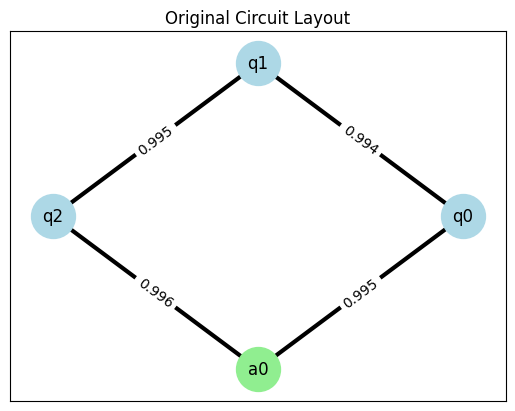

In [ ]:
import matplotlib.pyplot as plt

pos = nx.circular_layout(module)
nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["q0", "q1", "q2"], node_color="lightblue")
nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["a0"], node_color="lightgreen")
nx.draw_networkx_labels(module, pos, font_size=12, font_family="sans-serif")
nx.draw_networkx_edges(module, pos, width=3)
nx.draw_networkx_edge_labels(module, pos, edge_labels=nx.get_edge_attributes(module, "weight"))
plt.title("Original Circuit Layout")
plt.show()

[('q0', 'q1'), ('q0', 'a0'), ('q1', 'q2'), ('q2', 'a0')]
frozenset({('a0', 'q2'), ('q1', 'q0'), ('q2', 'q1'), ('q0', 'a0')})
frozenset({('a0', 'q2'), ('q1', 'q0'), ('q2', 'q1'), ('q0', 'a0')})


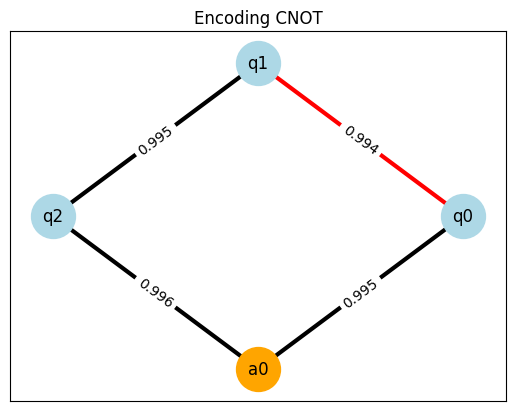

In [ ]:

off_edge_color = "#000000"
on_edge_color = "#FF0000"

active = {frozenset(("q0", "q1"))}

on_edges = [(u,v) for u, v in module.edges() if frozenset((u,v)) in active]
off_edges = [(u,v) for u, v in module.edges() if frozenset((u,v)) not in active]

pos = nx.circular_layout(module)
nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["q0", "q1", "q2"], node_color="lightblue")
nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["a0"], node_color="orange")
nx.draw_networkx_labels(module, pos, font_size=12, font_family="sans-serif")
nx.draw_networkx_edges(module, pos, edgelist=on_edges, edge_color=on_edge_color, width=3, alpha=1)
nx.draw_networkx_edges(module, pos, edgelist=off_edges, edge_color= off_edge_color, width=3, alpha= 1)
nx.draw_networkx_edge_labels(module, pos, edge_labels=nx.get_edge_attributes(module, "weight"))
plt.title("Encoding CNOT")
plt.savefig("images/1.png")

In [74]:
module.edges[("q0","q1")]['weight']

0.994

In [112]:
def perform_cns_gate(module:nx.Graph, active_edge, init_fidelity, title, image_num):

    print(active_edge)
    # Canonical form: each edge is a frozenset of its two endpoints
    active = {frozenset(("q0", "q1"))}
    off_edges = [(u, v) for u, v in module.edges() if frozenset((u, v)) not in active]
    print(off_edges)
    off_edge_color = "#000000"
    on_edge_color = "#FF0000"


    fidelity = init_fidelity * module.edges[active_edge]["weight"]

    # Highlight the CNS gate edge
    pos = nx.circular_layout(module)
    nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["q0", "q1", "q2"], node_color="lightblue")
    nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["a0"], node_color="orange")
    nx.draw_networkx_labels(module, pos, font_size=12, font_family="sans-serif")
    nx.draw_networkx_edges(module, pos, edgelist=[active_edge], edge_color=on_edge_color, width=3, alpha=1)
    nx.draw_networkx_edges(module, pos, edgelist=off_edges, edge_color= off_edge_color, width=3, alpha= 1)
    nx.draw_networkx_edge_labels(module, pos, edge_labels=nx.get_edge_attributes(module, "weight"))
    plt.title(f"{title} - Fidelity: {init_fidelity:.3f}")
    plt.savefig(f"images/{image_num}.png")
    plt.close()
    
    # Perform SWAP
    mapping = {active_edge[0]: active_edge[1], active_edge[1]: active_edge[0]}
    module = nx.relabel_nodes(module, mapping, copy=True)
    nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["q0", "q1", "q2"], node_color="lightblue")
    nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["a0"], node_color="orange")
    nx.draw_networkx_labels(module, pos, font_size=12, font_family="sans-serif")
    nx.draw_networkx_edges(module, pos, edgelist=[active_edge], edge_color=on_edge_color, width=3, alpha=1)
    nx.draw_networkx_edges(module, pos, edgelist=off_edges, edge_color= off_edge_color, width=3, alpha= 1)
    nx.draw_networkx_edge_labels(module, pos, edge_labels=nx.get_edge_attributes(module, "weight"))
    plt.title(f"{title} - Fidelity: {fidelity:.3f}")
    plt.savefig(f"images/{image_num+1}.png")
    plt.close()

    return fidelity, image_num+2

In [102]:
module.edges()

EdgeView([('q0', 'q1'), ('q0', 'a0'), ('q1', 'q2'), ('q2', 'a0')])

In [113]:
perform_cns_gate(module, ("q0", "q1"), 1., "First CNS", 0)

('q0', 'q1')
[('q0', 'a0'), ('q1', 'q2'), ('q2', 'a0')]


(0.994, 2)

# 5Q 6Gate Work

In [ ]:
import itertools
perms = list(itertools.permutations(["q0", "q1", "q2", "a0", "a1"]))

In [ ]:
circuit = [

]

In [ ]:
for perm in perms:
    module = nx.Graph()
    q0, q1, q2, a0, a1 = perm
    module.add_nodes_from(["q0", "q1", "q2", "a0", "a1"])
    module.add_edge(q0, q1, weight=0.989)
    module.add_edge(q1, q2, weight=0.973)
    module.add_edge(q2, a1, weight=0.962)
    module.add_edge(q1, a1, weight=0.960)
    module.add_edge(q0, a0, weight=0.968)
    module.add_edge(q1, a0, weight = 0.968)
    module.add_edge(a0, a1, weight = 0.98)